# 02 - Exploratory Data Analysis (EDA)
Goal: understand distributions, relationships, and correlations to guide feature choices for modeling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/50_Startups_dataset.csv', index_col=0)
num_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.30,136897.90,471784.20,New York,192261.93
1,162597.80,151377.69,443898.63,California,191792.16
2,153441.61,101145.65,407934.64,Florida,191050.49
3,144372.51,118671.95,383199.72,New York,182902.09
4,142107.44,91391.87,366168.52,Florida,166188.04


## 1. Distributions of numeric features

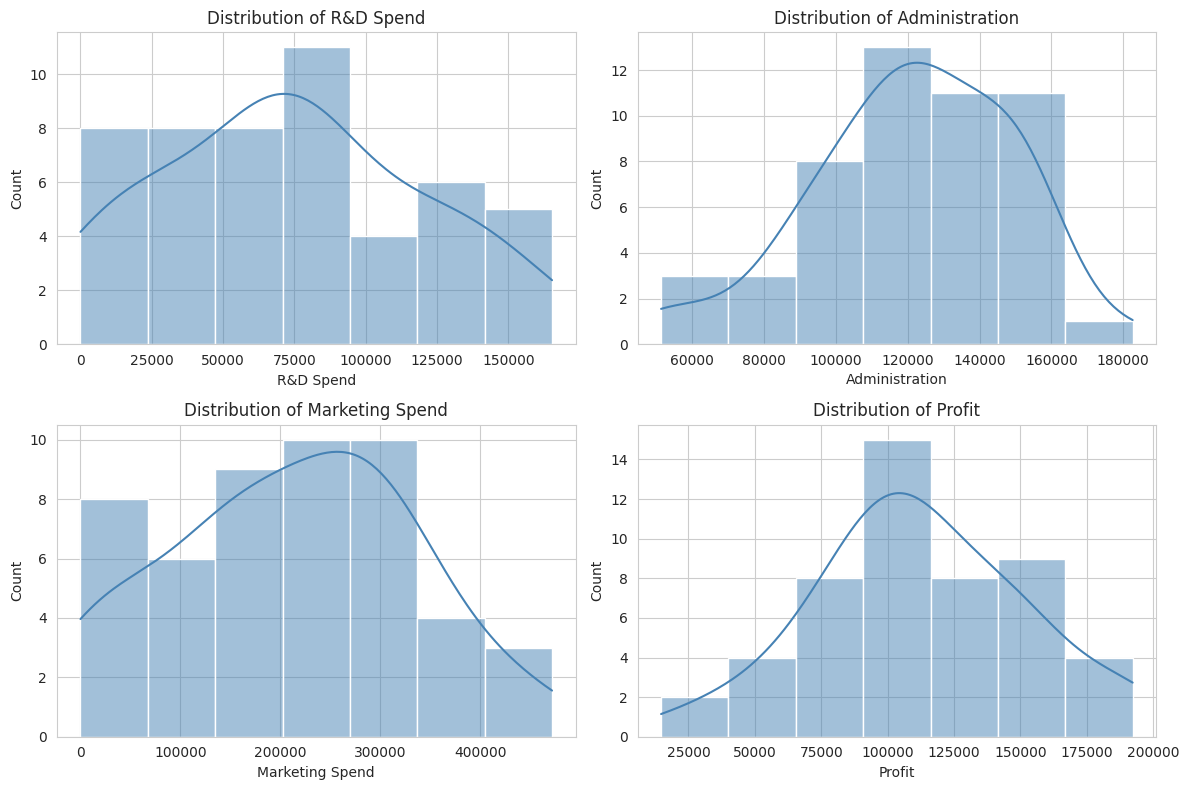

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('../outputs_eda_distributions.png', dpi=100)
plt.show()

## 2. Boxplots (outlier check)

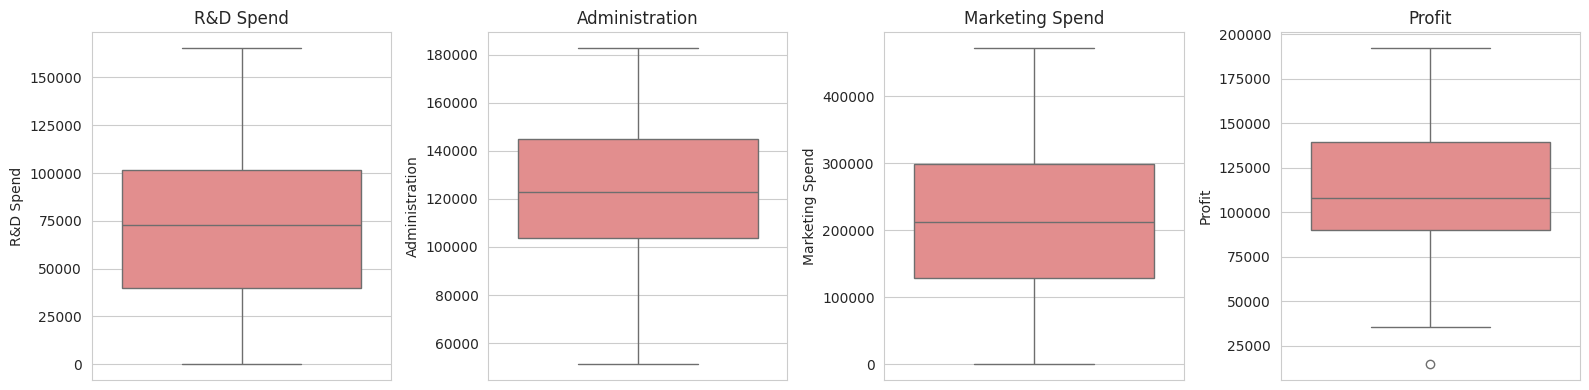

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Profit by State

/tmp/ipykernel_158/572067061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='State', y='Profit', palette='Set2')


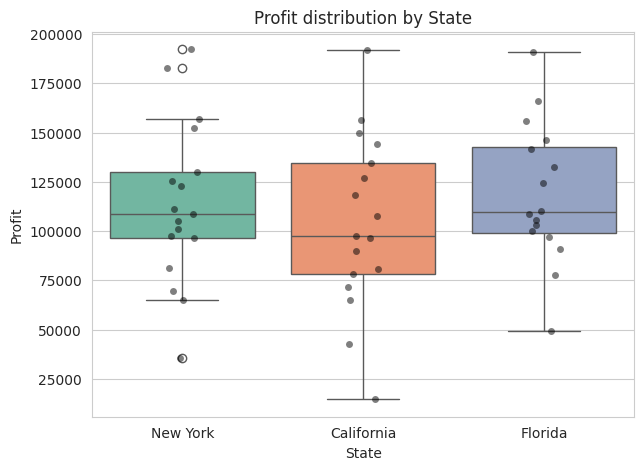

,mean,median,std,count
State,,,,
California,103905.275294,97427.94,44446.359357,17
Florida,118774.124375,109543.22,35605.470428,16
New York,113756.546471,108552.14,41140.258117,17


In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='State', y='Profit', palette='Set2')
sns.stripplot(data=df, x='State', y='Profit', color='black', alpha=0.5, jitter=True)
plt.title('Profit distribution by State')
plt.show()

df.groupby('State')['Profit'].agg(['mean','median','std','count'])

## 4. Correlation matrix

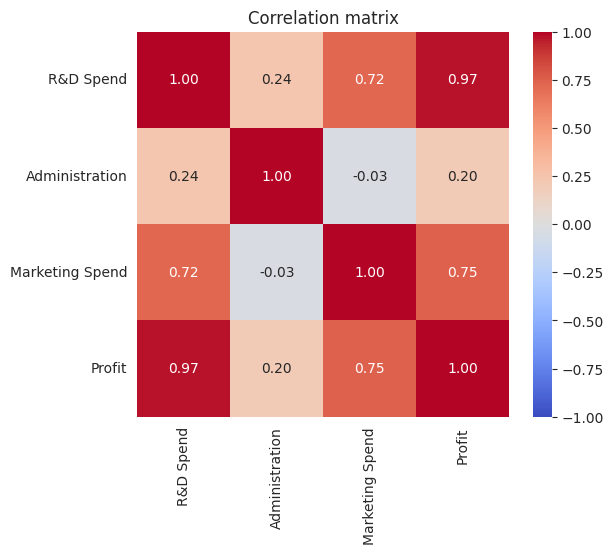

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


In [ ]:
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()
corr

## 5. Scatter plots vs Profit (target)

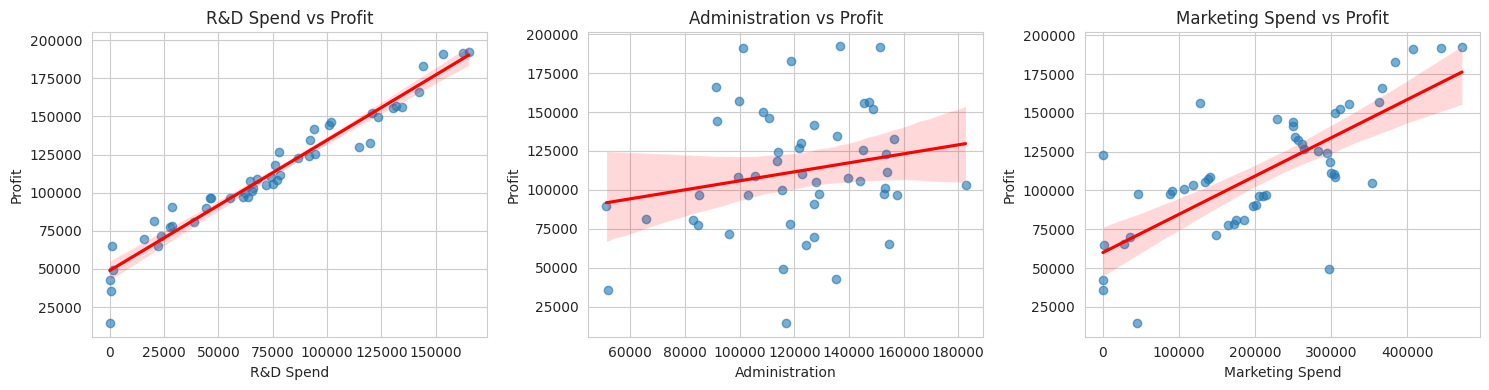

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['R&D Spend','Administration','Marketing Spend']):
    sns.regplot(data=df, x=col, y='Profit', ax=ax, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    ax.set_title(f'{col} vs Profit')
plt.tight_layout()
plt.show()

## 6. Pairplot

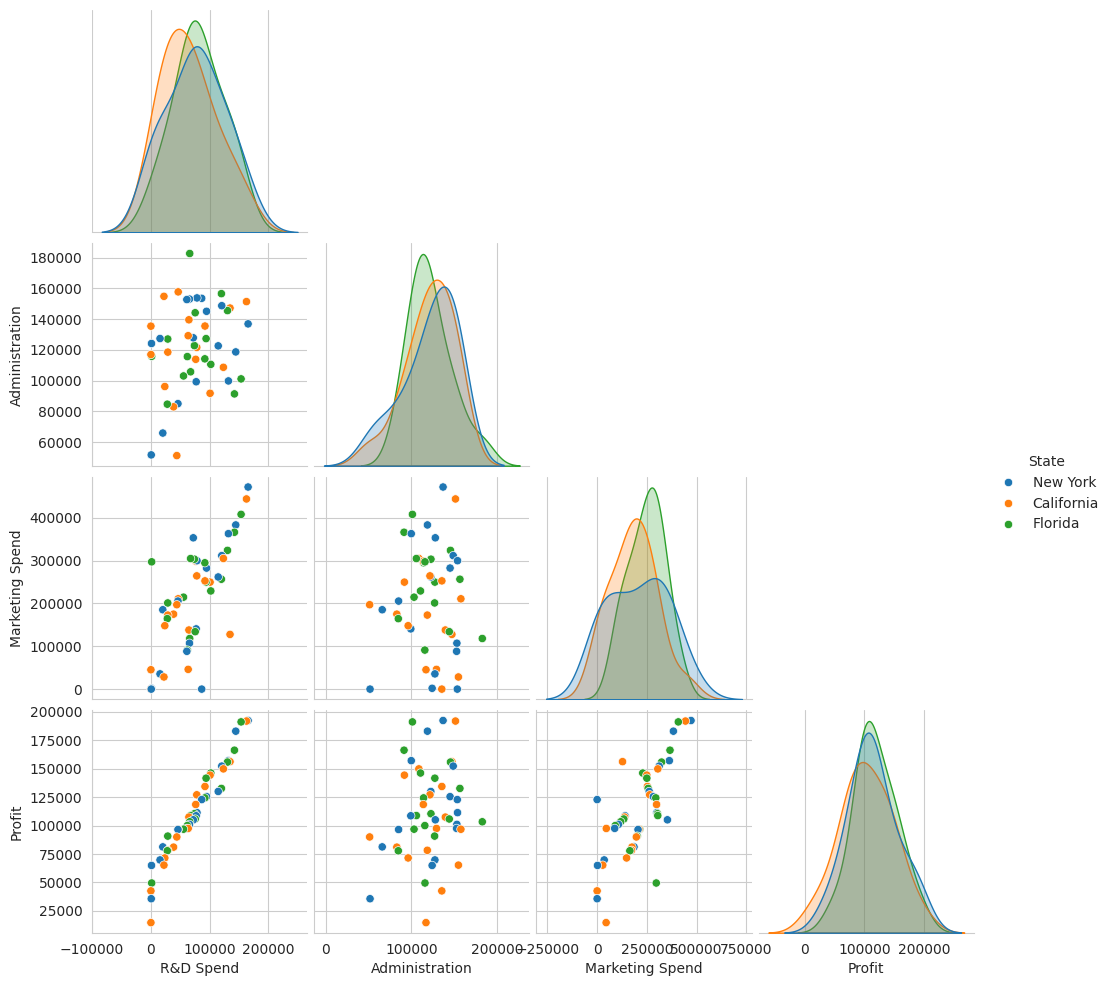

In [ ]:
sns.pairplot(df, vars=num_cols, hue='State', corner=True)
plt.show()

## EDA Findings

- **R&D Spend is by far the strongest predictor of Profit** (correlation ≈ 0.97), with an almost linear relationship.
- **Marketing Spend** has a moderate positive correlation with Profit (≈ 0.75), and is itself correlated with R&D Spend (≈ 0.72) — potential multicollinearity.
- **Administration** has a weak correlation with Profit (≈ 0.20) — likely a low-value predictor.
- **State** shows no strong effect on Profit — mean profit is similar across New York, California, and Florida; likely safe to keep as a weak categorical feature or drop it.
- No major outliers beyond a couple of low-spend startups with correspondingly lower profit — consistent with the trend, not data errors.
- **Implication for modeling:** R&D Spend will dominate; Marketing Spend adds some signal; Administration and State add little, and R&D/Marketing correlation means linear models should be checked for multicollinearity (e.g. via VIF) or simply accepted since tree-based models are unaffected.